In [2]:
%%capture --no-stderr
%pip install -U langgraph langsmith

# Used for this tutorial; not a requirement for LangGraph
%pip install -U langchain_anthropic

In [3]:
%%capture --no-stderr
%pip -q install -U langchain-nomic langchain_community tiktoken langchainhub chromadb langchain langgraph tavily-python gpt4all langchain-text-splitters

In [4]:
#_set_env("LANGSMITH_API_KEY")
#os.environ["LANGCHAIN_TRACING_V2"] = "true"
#os.environ["LANGCHAIN_PROJECT"] = "LangGraph Tutorial"

In [5]:
!ollama pull llama3

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest 
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB                         
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB                         
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B                         
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B                         
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B                         
verifying sha256 digest ⠋ pulling manifest 
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB                         
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB                         
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B                         
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B                         
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B                         
verifying sha256 digest ⠙ pulling manifest 
pulling 6a0746a1ec

In [2]:
import json

In [2]:
f = open('/Users/andrea/Documents/git/access_layer/biomarker_analyses/member_personas_content.json')

data = json.load(f)

In [3]:
member_context = list(filter(lambda x: x['patient_id'] == '0014a36bede92b2abb61854adbae5f725ce12208f2e33d897fe6d40b4a9c0bcb', data))

In [4]:
member_context

[{'patient_id': '0014a36bede92b2abb61854adbae5f725ce12208f2e33d897fe6d40b4a9c0bcb',
  'requisition_id': '02f544a2b222819fa351287dce921b4b8729d168212f08c1fbaf85b936c35ffb',
  'diet': ['Omnivore'],
  'physically_active': [False],
  'smoker': [False],
  'sex': ['Female'],
  'alcohol': [False],
  'alcohol_frequency': [None],
  'Over_Range': ['ldl medium',
   'ldl particle number',
   'ldl peak size',
   'ldl small',
   'ldl-cholesterol'],
  'Under_Range': ['hdl large'],
  'Outof_Range': [],
  'identified_medications': 'berberine, iron, magnesium, glycine, fish oil',
  'conditions': ['obesity'],
  'content': '<p>Your cholesterol was a little elevated. This can be related to both diet and/or genetics. </p><p>The small dense "bad" LDL cholesterol was elevated. </p><p>Your total HDL, the “good” cholesterol was high which is protective. However, your Large HDL particles were less than optimal which may be associated with an increased risk of cardiovascular disease, even if the total HDL level i

In [6]:
project_id = "function-health-dev-env"  # @param {type:"string"}
database_password = "FunctionHealth"  # @param {type:"string"}
region = "us-central1"  # @param {type:"string"}
instance_name = "development-ac-poc"  # @param {type:"string"}
database_name = "poc"  # @param {type:"string"}
database_user = "ac-dev"  # @param {type:"string"}

In [4]:


# Configure gcloud.
!gcloud config set project "function-health-dev-env"

# Grant Cloud SQL Client role to authenticated user
current_user = !gcloud auth list --filter=status:ACTIVE --format="value(account)"

!gcloud projects add-iam-policy-binding function-health-dev-env \
  --member="user:andrea.constantinof@functionhealth.com" \
  --role="roles/cloudsql.client"\
  --condition='None'
  



Updated property [core/project].


Updates are available for some Google Cloud CLI components.  To install them,
please run:
  $ gcloud components update

ERROR: (gcloud.projects.add-iam-policy-binding) User [andrea.constantinof@functionhealth.com] does not have permission to access projects instance [function-health-dev-env:setIamPolicy] (or it may not exist): Policy update access denied.


In [5]:
# Enable Cloud SQL Admin API
!gcloud services enable sqladmin.googleapis.com
!gcloud services enable aiplatform.googleapis.com

In [7]:
#@markdown Create and setup a Cloud SQL PostgreSQL instance, if not done already.
database_version = !gcloud sql instances describe {instance_name} --format="value(databaseVersion)"
if database_version[0].startswith("POSTGRES"):
  print("Found an existing Postgres Cloud SQL Instance!")
  print(database_version)
else:
  print("Creating new Cloud SQL instance...")
  !gcloud sql instances create {instance_name} --database-version=POSTGRES_15 \
    --region={region} --cpu=1 --memory=4GB --root-password={database_password}

# Create the database, if it does not exist.
out = !gcloud sql databases list --instance={instance_name} --filter="NAME:{database_name}" --format="value(NAME)"
if ''.join(out) == database_name:
  print("Database %s already exists, skipping creation." % database_name)
else:
  !gcloud sql databases create {database_name} --instance={instance_name}

# Create the database user for accessing the database.
!gcloud sql users create {database_user} \
  --instance={instance_name} \
  --password={database_password}

Found an existing Postgres Cloud SQL Instance!
['POSTGRES_15']
Database poc already exists, skipping creation.
Creating Cloud SQL user...done.                                                
Created user [ac-dev].


In [21]:
# @markdown Verify that you are able to connect to the database. Executing this block should print the current PostgreSQL server version.

import asyncio
import asyncpg
from google.cloud.sql.connector import Connector


async def main():
    # get current running event loop to be used with Connector
    loop = asyncio.get_running_loop()
    # initialize Connector object as async context manager
    async with Connector(loop=loop) as connector:
        # create connection to Cloud SQL database
        conn: asyncpg.Connection = await connector.connect_async(
            f"{project_id}:{region}:{instance_name}",  # Cloud SQL instance connection name
            "asyncpg",
            user=f"{database_user}",
            password=f"{database_password}",
            db=f"{database_name}"
            # ... additional database driver args
        )

        # query Cloud SQL database
        results = await conn.fetch("SELECT version()")
        print(results[0]["version"])

        # close asyncpg connection
        await conn.close()


# Test connection with `asyncio`
await main()  # type: ignore

PostgreSQL 15.7 on x86_64-pc-linux-gnu, compiled by Debian clang version 12.0.1, 64-bit


In [2]:
import pandas as pd
import numpy as np
import os
from langchain.document_loaders import PyPDFLoader, UnstructuredPDFLoader, PyPDFium2Loader
from langchain.document_loaders import PyPDFDirectoryLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from pathlib import Path
import random

In [8]:
docs = os.listdir('/Users/andrea/Documents/git/poc_data')

In [9]:
docs

['Apolipoprotein B.pdf', 'Total Cholesterol.pdf', 'LDL Cholesterol.pdf']

In [10]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import GPT4AllEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.embeddings import VertexAIEmbeddings
from google.cloud import aiplatform
import time

docs = [PyPDFLoader(f'/Users/andrea/Documents/git/poc_data/{url}').load() for url in docs]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

aiplatform.init(project=f"{project_id}", location=f"{region}")




In [9]:
aiplatform.init(project=f"{project_id}", location=f"{region}")

In [11]:
import ollama

In [12]:
doc_splits[0].page_content

'Apolipopr otein\nB\nWhy\nit\nmatters?\nWhile\nmany\nthink\nthat\nlow-density\nlipoprotein\ncholesterol\n(LDL)\nis\nthe\nbiggest\nrisk\nfactor\nfor\npredicting\nheart\ndisease,\nit\nis\nnot.\nWhat\nis\nmore\nimportant\nthan\nLDL\nlevel\nis\nthe\namount\nof\napolipoprotein\nB\n(ApoB)\nparticles.\nFat\nand\nwater\ndon’t\nmix.\nAnd\nin\nthe\nbody,\nthat’s\ncholesterol\nand\nblood.\nIn\norder\nfor\ncholesterol\nor\nlipid\nparticles\nto\nbe\ntransported\naround\nthe\nbody,\nthey\nmust\nbe\nenveloped\nin\na\nprotein\nmolecule.\nHence\nthe\nterm\nlipoprotein.\nApolipoprotein\nB\nis\nthe\nmain\nprotein\ncarrier\nfor\nLDL,\nHDL,\nand\nVLDL\nparticles.'

In [13]:
line_List = [doc.page_content for doc in doc_splits]


In [14]:
doc_splits[0].page_content

'Apolipopr otein\nB\nWhy\nit\nmatters?\nWhile\nmany\nthink\nthat\nlow-density\nlipoprotein\ncholesterol\n(LDL)\nis\nthe\nbiggest\nrisk\nfactor\nfor\npredicting\nheart\ndisease,\nit\nis\nnot.\nWhat\nis\nmore\nimportant\nthan\nLDL\nlevel\nis\nthe\namount\nof\napolipoprotein\nB\n(ApoB)\nparticles.\nFat\nand\nwater\ndon’t\nmix.\nAnd\nin\nthe\nbody,\nthat’s\ncholesterol\nand\nblood.\nIn\norder\nfor\ncholesterol\nor\nlipid\nparticles\nto\nbe\ntransported\naround\nthe\nbody,\nthey\nmust\nbe\nenveloped\nin\na\nprotein\nmolecule.\nHence\nthe\nterm\nlipoprotein.\nApolipoprotein\nB\nis\nthe\nmain\nprotein\ncarrier\nfor\nLDL,\nHDL,\nand\nVLDL\nparticles.'

In [15]:
#Creating pandas database for vector store
#uses ollama embeddings
import pandas as pd
embeddings = []
for i in range(len(doc_splits)):
    response = ollama.embeddings(model="mxbai-embed-large", prompt=doc_splits[i].page_content)
    embeddings.append(response["embedding"])

pd_db_df = pd.DataFrame({'Document':[i.metadata for i in doc_splits[:len(embeddings)]],'Embeddings':embeddings,'Content':[i.page_content for i in doc_splits[:len(embeddings)]]})

In [16]:
pd_db_df.Document = str(pd_db_df.Document)

In [17]:
pd_db_df.Document = pd_db_df.Document.replace("{", '')
pd_db_df.Document = pd_db_df.Document.replace("}", '')

In [18]:
pd_db_df.head()

,Document,Embeddings,Content
0,0 {'source': '/Users/andrea/Documents/git...,"[0.1515687108039856, 0.5590774416923523, 0.442...",Apolipopr otein\nB\nWhy\nit\nmatters?\nWhile\n...
1,0 {'source': '/Users/andrea/Documents/git...,"[0.16688036918640137, 0.3238402009010315, 0.73...",VLDL\nis\na\nmeasure\nof\nthe\nlipoproteins\nt...
2,0 {'source': '/Users/andrea/Documents/git...,"[-0.20602142810821533, 0.18391920626163483, 0....",measure\nof\nthe\nnumber\nand\nsize\nof\nchole...
3,0 {'source': '/Users/andrea/Documents/git...,"[-0.2942020297050476, 0.3417237102985382, 0.54...",are\nlarge\nnumbers\nof\nsmall\nLDL\nparticles...
4,0 {'source': '/Users/andrea/Documents/git...,"[-0.29044121503829956, 1.1105916500091553, 0.2...","cells\nknown\nas\nmacrophages,\nbecoming\n'foa..."


In [19]:
pd_db_df.to_csv('embeddings1.csv', index = False)

In [106]:
table_name = "data_set1"

In [108]:
# Store the generated vector embeddings in a PostgreSQL table.
# This code may run for a few minutes.

import asyncio
import asyncpg
from google.cloud.sql.connector import Connector
import numpy as np
from pgvector.asyncpg import register_vector


async def main():
    loop = asyncio.get_running_loop()
    async with Connector(loop=loop) as connector:
        # Create connection to Cloud SQL database.
        conn: asyncpg.Connection = await connector.connect_async(
            f"{project_id}:{region}:{instance_name}",  # Cloud SQL instance connection name
            "asyncpg",
            user=f"{database_user}",
            password=f"{database_password}",
            db=f"{database_name}",
        )

        await conn.execute("CREATE EXTENSION IF NOT EXISTS vector")
        await register_vector(conn)

        await conn.execute("DROP TABLE IF EXISTS data_set1")
        # Create the `product_embeddings` table to store vector embeddings.
        await conn.execute(
            """CREATE TABLE data_set1(
                                Document VARCHAR(1024),
                                content TEXT,
                                embedding vector(1024))"""
        )

        # Store all the generated embeddings back into the database.
        for index, row in pd_db_df.iterrows():
            await conn.execute(
                "INSERT INTO data_set1 (Document, content, embedding) VALUES ($1, $2, $3)",
                row["Document"],
                row["Content"],
                np.array(row["Embeddings"]),
            )

        await conn.close()


# Run the SQL commands now.
await main()  # type: ignore

In [ ]:
project_id = "function-health-dev-env"  # @param {type:"string"}
database_password = "FunctionHealth"  # @param {type:"string"}
region = "us-central1"  # @param {type:"string"}
instance_name = "development-ac-poc"  # @param {type:"string"}
database_name = "poc"  # @param {type:"string"}
database_user = "ac-dev"  # @param {type:"string"}

In [11]:
#import pg8000
import os
from google.cloud.sql.connector import Connector
from langchain_google_vertexai import VertexAI
from langchain_google_vertexai import VertexAIEmbeddings
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_community.vectorstores.pgvector import PGVector

In [13]:
import asyncio
import asyncpg
from google.cloud.sql.connector import Connector
import numpy as np
from pgvector.asyncpg import register_vector

In [18]:
async def async_main():
    async with engine.connect() as conn:
        tables = await conn.run_sync(
            lambda sync_conn: inspect(sync_conn).get_table_names()
        )

In [20]:
import sqlalchemy


def connect_with_connector() -> sqlalchemy.engine.base.Engine:
    """
    Initializes a connection pool for a Cloud SQL instance of MySQL.

    Uses the Cloud SQL Python Connector package.
    """
    # Note: Saving credentials in environment variables is convenient, but not
    # secure - consider a more secure solution such as
    # Cloud Secret Manager (https://cloud.google.com/secret-manager) to help
    # keep secrets safe.

    

    connector = Connector()

    def getconn() -> asyncpg.connections.Connection:
        conn: asyncpg.connections.Connection = connector.connect(
            instance_connection_name,
            "asyncpg",
            user=db_user,
            password=db_pass,
            db=db_name,
        )
        return conn

vectorstore = PGVector(
    connection_string="postgresql+asyncpg://",
    use_jsonb=True,
    engine_args=dict(
        creator=getconn,
           ),
    embedding_function= ollama.embeddings(
        model="mxbai-embed-large"
     )
     )


retriever = vectorstore.as_retriever()


NameError: name 'PGVector' is not defined

In [24]:
connector = Connector()


async def getconn():
    async with Connector() as connector:
        # Create connection to Cloud SQL database.
        conn: asyncpg.Connection = connector.connect_async(
            f"{project_id}:{region}:{instance_name}",  # Cloud SQL instance connection name
            "asyncpg",
            user=f"{database_user}",
            password=f"{database_password}",
            db=f"{database_name}",
        )
    return conn

vectorstore = PGVector(
    connection_string="postgresql+asyncpg://",
    use_jsonb=True,
    engine_args=dict(
        creator=getconn,
           ),
    embedding_function= ollama.embeddings(
        model="mxbai-embed-large"
    )
)
retriever = vectorstore.as_retriever()

Exception: Failed to create vector extension: greenlet_spawn has not been called and asyncio event loop is already running; can't call await_fallback() here. Was IO attempted in an unexpected place? (Background on this error at: https://sqlalche.me/e/20/xd2s)

In [111]:
# (1) Initialize VectorStore
connector = Connector()


def getconn() -> connector.connect_async(f"{project_id}:{region}:{instance_name}",  # Cloud SQL instance connection name
        "asyncpg",
        user=f"{database_user}",
        password=f"{database_password}",
        db=f"{database_name}",
        )  

    


vectorstore = PGVector(
    connection_string="postgresql+pg8000://",
    use_jsonb=True,
    engine_args=dict(
        creator=getconn,
)
)

# (2) Build retriever


def concatenate_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


notes_retriever = vectorstore.as_retriever() | concatenate_docs

# (3) Create prompt template
prompt_template = PromptTemplate.from_template(
    """You are a Cloud Run expert answering questions. 
Use the retrieved release notes to answer questions
Give a concise answer, and if you are unsure of the answer, just say so.

Release notes: {notes}

Here is your question: {query}
Your answer: """)

# (4) Initialize LLM
llm = VertexAI(
    model_name="gemini-1.0-pro-001",
    temperature=0.2,
    max_output_tokens=100,
    top_k=40,
    top_p=0.95
)

# (5) Chain everything together
chain = (
    RunnableParallel({
        "notes": notes_retriever,
        "query": RunnablePassthrough()
    })
    | prompt_template
    | llm
    | StrOutputParser()
)

SyntaxError: expected ':' (3831436397.py, line 10)

In [ ]:
vectorstore = PGVector(
    connection_string="postgresql+pg8000://",
    use_jsonb=True,
    engine_args=dict(
        creator=getconn,
    ),
    embedding_function=VertexAIEmbeddings(
        model_name="textembedding-gecko@003"
    )
)

In [ ]:
retriever = vectorstore.as_retriever()

In [4]:

from langchain_community.chat_models import ChatOllama

# Prompt
prompt = PromptTemplate(
    template="""<|begin_of_text|><|start_header_id|>system<|end_header_id|> You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. 
    Draw an image that summarizes your answer
    Use three sentences maximum and keep the answer concise <|eot_id|><|start_header_id|>user<|end_header_id|>
    Question: {question}
    Context: {context}
    Answer: <|eot_id|><|start_header_id|>assistant<|end_header_id|>""",
    input_variables=["question", "document"],
)

llm = ChatOllama(model=local_llm, temperature=0)
llm = ChatOllama(model = "llama3")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [5]:
graph_builder.add_edge(START, "chatbot")

In [6]:
graph_builder.add_edge("chatbot", END)

In [7]:
graph = graph_builder.compile()

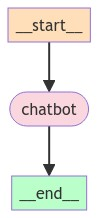

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

Assistant: The answer to this question largely depends on personal preferences, cultural traditions, and regional climate. That being said, I'll provide some insights based on various factors.

**Weather:**

* Spring (March to May) - Mild temperatures, blooming flowers, and greenery make it a popular choice.
* Autumn (September to November) - Comfortable temperatures, fewer crowds, and beautiful foliage are attractive qualities.
* Summer (June to August) - Warm weather, long days, and vacation seasons make it a favorite among many.

**Holiday season:**

* Winter (December to February) - Christmas, New Year's Eve, and other festive holidays create a magical atmosphere.
* Halloween (October 31st) - The spooky atmosphere and costume parties are a hit with many.

**Outdoor activities:**

* Summer - Swimming, hiking, camping, and water sports are popular during this season.
* Spring and Autumn - Milder temperatures make them ideal for outdoor activities like cycling, gardening, or picnics.
